In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

now we will load our data 

## phase 1 :reading the data of our project

In [10]:
df = pd.read_csv("The_Cancer_data_1500_V2.csv")  # Replace with your file path
df.head()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


## now we will unclean our data

In [11]:
df_unclean = df.copy()

# Introduce Missing Values
df_unclean.loc[10, 'Age'] = np.nan
df_unclean.loc[50, 'BMI'] = np.nan
df_unclean.loc[100:105, 'PhysicalActivity'] = np.nan

# Add Duplicates
df_unclean = pd.concat([df_unclean, df_unclean.iloc[0:5]], ignore_index=True)

# Add Outliers
df_unclean.loc[20, 'Age'] = -5
df_unclean.loc[21, 'BMI'] = 100
df_unclean.loc[22, 'AlcoholIntake'] = 20

# Typos / Wrong Values in Categorical
df_unclean.loc[30, 'Gender'] = 2
df_unclean.loc[31, 'GeneticRisk'] = 5

# Wrong Data Types
df_unclean['Smoking'] = df_unclean['Smoking'].astype(float)

# Inspect unclean dataset
print("=== Missing Values (Unclean) ===")
print(df_unclean.isna().sum())

print("\n=== Duplicates (Unclean) ===")
print(df_unclean[df_unclean.duplicated()])

print("\n=== Outliers Example (Age < 20 or Age > 80) ===")
print(df_unclean[(df_unclean['Age'] < 20) | (df_unclean['Age'] > 80)])

=== Missing Values (Unclean) ===
Age                 1
Gender              0
BMI                 1
Smoking             0
GeneticRisk         0
PhysicalActivity    6
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64

=== Duplicates (Unclean) ===
       Age  Gender        BMI  Smoking  GeneticRisk  PhysicalActivity  \
1500  58.0       1  16.085313      0.0            1          8.146251   
1501  71.0       0  30.828784      0.0            1          9.361630   
1502  48.0       1  38.785084      0.0            2          5.135179   
1503  34.0       0  30.040296      0.0            0          9.502792   
1504  62.0       1  35.479721      0.0            0          5.356890   

      AlcoholIntake  CancerHistory  Diagnosis  
1500       4.148219              1          1  
1501       3.519683              0          0  
1502       4.728368              0          1  
1503       2.044636              0          0  
1504       3.309849              0          1  

## phase 2: cleanning the data

In [12]:
df_clean = df_unclean.copy()

# Handle Missing Values
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].mean())
df_clean['BMI'] = df_clean['BMI'].fillna(df_clean['BMI'].mean())
df_clean['PhysicalActivity'] = df_clean['PhysicalActivity'].fillna(df_clean['PhysicalActivity'].mean())

# Remove Duplicates
df_clean = df_clean.drop_duplicates()

# Handle Outliers
df_clean['Age'] = df_clean['Age'].apply(lambda x: np.nan if x < 20 or x > 80 else x)
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].mean())

df_clean['BMI'] = df_clean['BMI'].apply(lambda x: np.nan if x < 15 or x > 40 else x)
df_clean['BMI'] = df_clean['BMI'].fillna(df_clean['BMI'].mean())

df_clean['AlcoholIntake'] = df_clean['AlcoholIntake'].apply(lambda x: np.nan if x < 0 or x > 5 else x)
df_clean['AlcoholIntake'] = df_clean['AlcoholIntake'].fillna(df_clean['AlcoholIntake'].mean())

# Fix Categorical Columns
df_clean['Gender'] = df_clean['Gender'].replace({2:0})
df_clean['GeneticRisk'] = df_clean['GeneticRisk'].replace({5:2})

# Correct Data Types
df_clean['Smoking'] = df_clean['Smoking'].astype(int)

# Verify Cleaning
print("\n=== Missing Values After Cleaning ===")
print(df_clean.isna().sum())

print("\n=== Duplicates After Cleaning ===")
print(df_clean[df_clean.duplicated()])

print("\n=== Unique values in categorical columns ===")
print("Gender:", df_clean['Gender'].unique())
print("Smoking:", df_clean['Smoking'].unique())
print("GeneticRisk:", df_clean['GeneticRisk'].unique())
print("CancerHistory:", df_clean['CancerHistory'].unique())


=== Missing Values After Cleaning ===
Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64

=== Duplicates After Cleaning ===
Empty DataFrame
Columns: [Age, Gender, BMI, Smoking, GeneticRisk, PhysicalActivity, AlcoholIntake, CancerHistory, Diagnosis]
Index: []

=== Unique values in categorical columns ===
Gender: [1 0]
Smoking: [0 1]
GeneticRisk: [1 2 0]
CancerHistory: [1 0]


## phase 3 :EDA

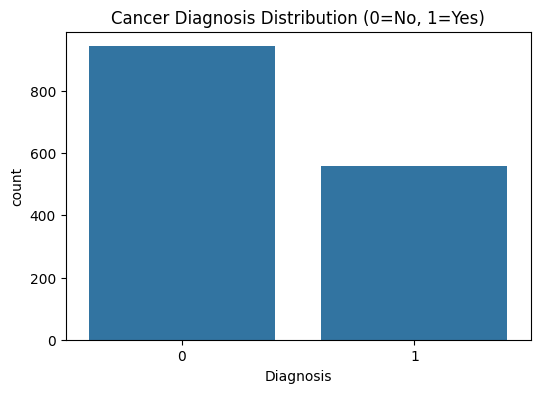

In [13]:
numeric_cols = ['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake']

plt.figure(figsize=(6,4))
sns.countplot(x='Diagnosis', data=df_clean)
plt.title("Cancer Diagnosis Distribution (0=No, 1=Yes)")
plt.show()




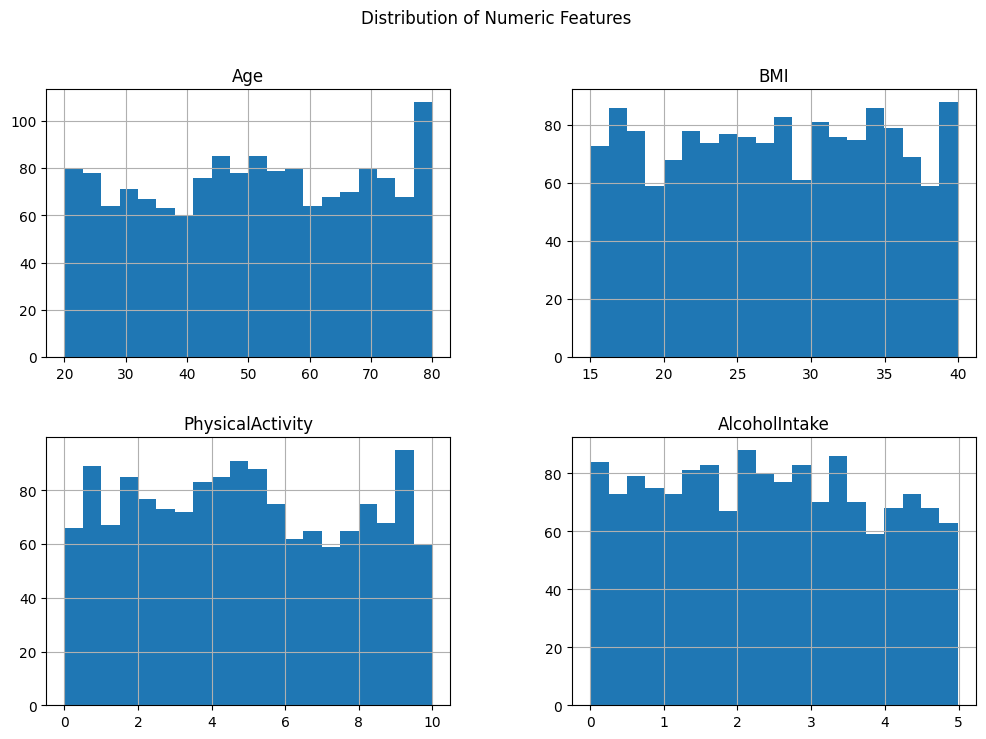

In [14]:
df_clean[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Numeric Features")
plt.show()

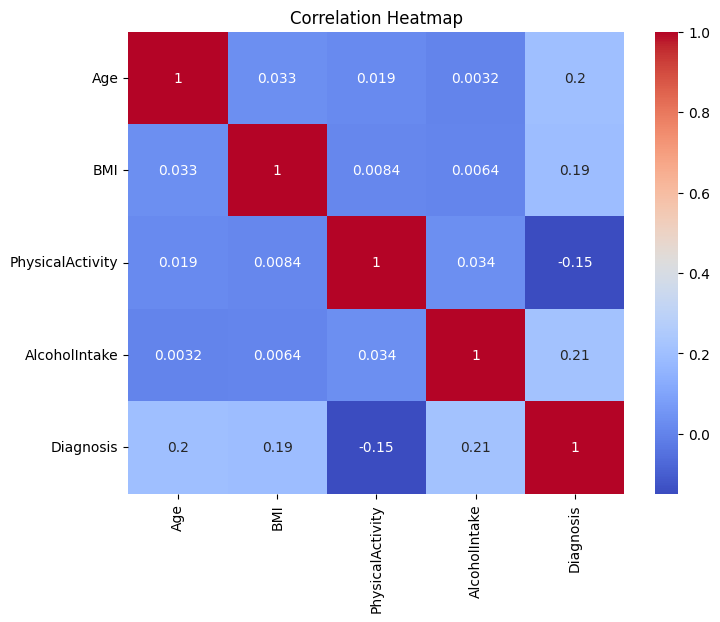

In [15]:


plt.figure(figsize=(8,6))
sns.heatmap(df_clean[numeric_cols + ['Diagnosis']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## phase 4: preprossing

In [16]:
cat_cols = ['Gender', 'Smoking', 'GeneticRisk', 'CancerHistory']
num_cols = numeric_cols

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

X = df_clean.drop(columns=['Diagnosis'])
y = df_clean['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



## phase 5 : modeling

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

predictions = {}
probas = {}
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]
    predictions[name] = y_pred
    probas[name] = y_proba

    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))


=== Logistic Regression ===
Confusion Matrix:
[[175   9]
 [ 19  97]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       184
           1       0.92      0.84      0.87       116

    accuracy                           0.91       300
   macro avg       0.91      0.89      0.90       300
weighted avg       0.91      0.91      0.91       300

ROC-AUC Score: 0.9538511994002998

=== Random Forest ===
Confusion Matrix:
[[175   9]
 [ 14 102]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       184
           1       0.92      0.88      0.90       116

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300

ROC-AUC Score: 0.9467766116941531


## phase six : comparison table 

In [18]:
comparison_df = pd.DataFrame({
    'Model': list(predictions.keys()),
    'Accuracy': [ (predictions[name] == y_test).mean() for name in predictions ],
    'ROC-AUC': [roc_auc_score(y_test, probas[name]) for name in predictions],
    'Precision (Cancer)': [classification_report(y_test, predictions[name], output_dict=True)['1']['precision'] for name in predictions],
    'Recall (Cancer)': [classification_report(y_test, predictions[name], output_dict=True)['1']['recall'] for name in predictions],
    'F1-score (Cancer)': [classification_report(y_test, predictions[name], output_dict=True)['1']['f1-score'] for name in predictions]
})


print("\n=== Model Comparison Table ===")
print(comparison_df.round(3))



=== Model Comparison Table ===
                 Model  Accuracy  ROC-AUC  Precision (Cancer)  \
0  Logistic Regression     0.907    0.954               0.915   
1        Random Forest     0.923    0.947               0.919   

   Recall (Cancer)  F1-score (Cancer)  
0            0.836              0.874  
1            0.879              0.899  


## phase 7 : Feature Importance (Random Forest)


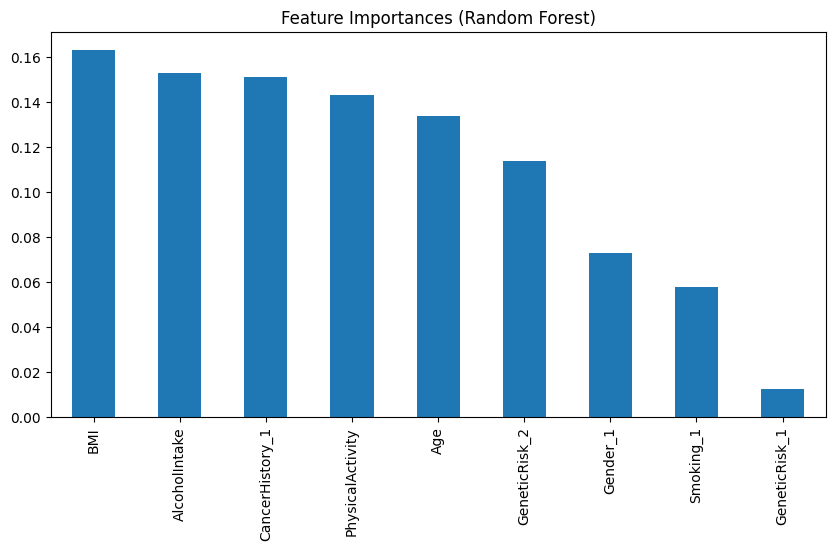

In [19]:
rf_model = Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
rf_model.fit(X_train, y_train)

ohe_cols = list(rf_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols))
all_features = num_cols + ohe_cols

importances = rf_model.named_steps['classifier'].feature_importances_
feat_importances = pd.Series(importances, index=all_features)
feat_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importances (Random Forest)")
plt.show()


## phase 8 :prediction Example

In [20]:
def predict_patient(patient_df):
    pred = rf_model.predict(patient_df)
    prob = rf_model.predict_proba(patient_df)[:,1]
    return pred[0], prob[0]

new_patient = pd.DataFrame({
    'Age': [55],
    'Gender': [0],
    'BMI': [28],
    'Smoking': [0],
    'GeneticRisk': [2],
    'PhysicalActivity': [3],
    'AlcoholIntake': [1],
    'CancerHistory': [1]
})

prediction, probability = predict_patient(new_patient)
print("\nPrediction (0=No Cancer, 1=Cancer):", prediction)
print("Probability of Cancer:", round(probability,3))



Prediction (0=No Cancer, 1=Cancer): 1
Probability of Cancer: 0.95


## Finall phase :Model saving

In [21]:
import joblib

# نستخدم Random Forest (أفضل موديل)
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

final_model.fit(X_train, y_train)

# حفظ الموديل
joblib.dump(final_model, "crc_model.pkl")

print("Model saved successfully!")

Model saved successfully!
